# Checkpoint 2 - Model Training & Baseline Comparison

**Women Safety & Smart Protection Platform - Divisi MLOps**

Notebook ini menjalankan dan mendokumentasikan seluruh pekerjaan Checkpoint 2:

1. Protokol evaluasi tiga-lapis (acak, holdout spasial, slot malam)
2. Tangga baseline non-ML empat tingkat
3. Kandidat model dan pemilihan champion multi-kriteria
4. Ablasi terkontrol target encoding (kritik terhadap referensi HO2)
5. Evaluasi bersegmen dan permutation importance
6. Penyimpanan bundle model, registry, metrics, dan output JSON untuk Front-End

Seluruh logika inti hidup di modul `src/` dan `features.py` (tidak diubah dari
CP1) - notebook ini hanya mengorkestrasi, menarasikan, dan memvisualisasikan
pemanggilan modul yang sama, persis seperti `train.py` dan REST API (`api/`).
Tidak ada logika yang disalin ulang di sini.

**Ruang lingkup**: HANYA Model Training & Baseline Comparison dan REST API
Serving (lihat notebook ini + `api/`). Continual learning, drift detection,
retraining berkala, monitoring, dan slide adalah lingkup Checkpoint 3 - lihat
`README.md` bagian "Catatan lingkup CP2 vs CP3" untuk detail kesiapan arsitektur.


In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import features as F
import src.baselines as baselines
import src.evaluation as evaluation
import src.modeling as modeling
import src.registry as registry
import src.splits as splits
import src.viz as viz
from src.config import (
    DISCLAIMER, FIGURES_DIR, LABEL_PARAMS_PATH, METRICS_PATH, MODEL_BUNDLE_PATH,
    MODEL_VERSION, OUTPUT_JSON_PATH, RANDOM_STATE, REGISTRY_PATH, risk_level,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
np.random.seed(RANDOM_STATE)

print(f"RANDOM_STATE terkunci di: {RANDOM_STATE}")
print(f"Root proyek: {ROOT_DIR}")


RANDOM_STATE terkunci di: 42
Root proyek: /Users/fransiskaadinda/Downloads/sistech/FP_MLOps_Kelompok 1


## 1. Muat dataset dan tinjauan singkat

`features_labels.csv` adalah hasil Checkpoint 1: 732 `cell_id` unik x 168 slot
waktu (7 hari x 24 jam) = 122.976 baris, cross-product lengkap tanpa baris
hilang dan tanpa NaN. Dataset **tidak diregenerasi** di sini - CP2 hanya
mengonsumsinya.

Satu baris merepresentasikan **profil agregat lintas tahun** untuk satu sel
grid pada satu kombinasi (hari, jam), bukan satu observasi kejahatan
bertanggal. Konsekuensi metodologis pentingnya dibahas di bagian 3.


In [2]:
df = splits.load_dataset()
with open(LABEL_PARAMS_PATH) as f:
    label_params = json.load(f)

print(f"Shape: {df.shape}")
print(f"Sel unik: {df['cell_id'].nunique()} | Total baris: {len(df):,}")
print(f"reference_date (label_params): {label_params['reference_date']}")
df.describe().round(2)


Shape: (122976, 16)
Sel unik: 732 | Total baris: 122,976
reference_date (label_params): 2026-04-11 00:00:00


,dow,hour,lat_r,lon_r,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,crime_count,violent_share,arrest_rate,cell_total_count,neighbor_count_mean,risk_score
count,122976.0,122976.00,122976.00,122976.00,122976.00,122976.00,122976.00,122976.00,122976.00,122976.00,122976.00,122976.00,122976.00,122976.00,122976.00
mean,3.0,11.50,41.84,-87.69,0.29,-0.00,-0.00,-0.00,-0.00,8.51,0.24,0.09,1430.36,8.29,43.03
std,2.0,6.92,0.11,0.09,0.45,0.71,0.71,0.71,0.71,11.24,0.25,0.16,1593.98,7.91,22.75
min,0.0,0.00,41.64,-87.94,0.00,-1.00,-1.00,-0.97,-0.90,0.00,0.00,0.00,1.00,0.00,0.00
25%,1.0,5.75,41.75,-87.74,0.00,-0.71,-0.71,-0.78,-0.90,1.00,0.00,0.00,270.50,2.12,25.03
50%,3.0,11.50,41.84,-87.69,0.00,0.00,-0.00,0.00,-0.22,5.00,0.21,0.00,1029.00,6.25,42.06
75%,5.0,17.25,41.94,-87.63,1.00,0.71,0.71,0.78,0.62,12.00,0.40,0.15,2089.00,12.25,59.04
max,6.0,23.00,42.02,-87.52,1.00,1.00,1.00,0.97,1.00,339.00,1.00,1.00,17372.00,89.75,100.00


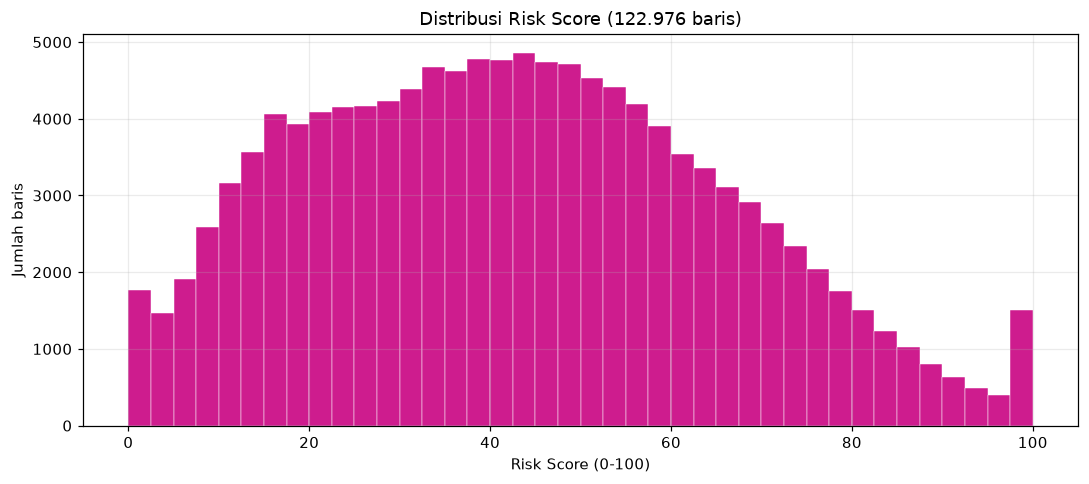

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(df["risk_score"], bins=40, color=viz.ACCENT, edgecolor="white", linewidth=0.3)
ax.set_title("Distribusi Risk Score (122.976 baris)")
ax.set_xlabel("Risk Score (0-100)")
ax.set_ylabel("Jumlah baris")
plt.tight_layout()
viz.savefig(fig, "01_distribusi_risk_score")
plt.show()


## 2. Protokol evaluasi tiga-lapis

Baseline dan model **wajib dievaluasi pada split yang identik**. Tiga protokol:

| Protokol | Cara split | Pertanyaan | Peran |
| :-- | :-- | :-- | :-- |
| A. Acak | `train_test_split` 80/20 | Interpolasi di grid yang sudah dikenal? | Pembanding dengan HO2, **bukan klaim generalisasi** |
| B. Holdout spasial | `GroupShuffleSplit` by `cell_id` | Model bisa menilai lokasi belum pernah dilihat? | **Angka headline / klaim generalisasi utama** |
| C. Slot malam | subset jam 21.00-03.00 dari test B | Akurat pada kondisi paling relevan pengguna? | Relevansi produk |

**Holdout temporal tidak mungkin di CP2**: satu baris adalah profil agregat
lintas tahun (bukan observasi bertanggal), sehingga tidak ada sumbu waktu yang
bisa dipotong untuk membentuk cutoff temporal yang jujur. Regenerasi snapshot
pada cutoff tanggal yang lebih baru (mengulang pipeline CP1 dengan
`reference_date` berbeda) adalah pekerjaan Checkpoint 3.

Verifikasi wajib: persentase baris test dengan sel tak dikenal harus mendekati
0% pada protokol A dan 100% pada protokol B - kontras inilah bukti bahwa
protokol A tidak mengukur generalisasi.


In [4]:
protocols = splits.build_all_protocols(df)
stats = protocols["stats"]

print("Verifikasi sel tak dikenal:")
print(f"  Protokol A (acak)          : {stats['A_unseen_cell_pct']:.2f}% baris test bersel tak dikenal")
print(f"  Protokol B (holdout spasial): {stats['B_unseen_cell_pct']:.2f}% baris test bersel tak dikenal")
print()
print(f"  A -> train {stats['A_train_rows']:,} baris | test {stats['A_test_rows']:,} baris")
print(f"  B -> train {stats['B_train_rows']:,} baris | test {stats['B_test_rows']:,} baris")
print(f"  C -> test {stats['C_test_rows']:,} baris (subset jam 21.00-03.00 dari test B)")

assert stats["A_unseen_cell_pct"] < 1.0, "Protokol A seharusnya nyaris 0% sel tak dikenal"
assert stats["B_unseen_cell_pct"] == 100.0, "Protokol B seharusnya 100% sel tak dikenal"
print("\nVerifikasi lulus: kontras protokol A vs B sesuai ekspektasi.")


Verifikasi sel tak dikenal:
  Protokol A (acak)          : 0.00% baris test bersel tak dikenal
  Protokol B (holdout spasial): 100.00% baris test bersel tak dikenal

  A -> train 98,380 baris | test 24,596 baris
  B -> train 98,280 baris | test 24,696 baris
  C -> test 7,203 baris (subset jam 21.00-03.00 dari test B)

Verifikasi lulus: kontras protokol A vs B sesuai ekspektasi.


## 3. Tangga baseline non-ML, empat tingkat

Bukan satu baseline, tapi tangga - tujuannya mendekomposisi sumber sinyal:

1. **Global mean** - lantai absolut.
2. **Rata-rata per `cell_id`** - pola spasial murni.
3. **Rata-rata per `(dow, hour)`** - pola temporal murni.
4. **Rata-rata per `(cell_id, hour)` dengan shrinkage** - baseline TERKUAT,
   inilah yang harus dikalahkan model. Konstanta shrinkage `m` dipilih lewat
   validasi INTERNAL dari train (test set tidak disentuh).

Adaptasi dari `fit_group_baseline` / `predict_group_baseline` (HO2) - bagian
yang diadopsi sesuai kritik referensi (lihat README).


In [5]:
ladder_a = baselines.fit_baseline_ladder(protocols["A"]["train"])
ladder_b = baselines.fit_baseline_ladder(protocols["B"]["train"])
ladders = {"A": ladder_a, "B": ladder_b, "C": ladder_b}

print(f"Shrinkage m terpilih (validasi internal train) - protokol A: {ladder_a['best_m']}")
print(f"Shrinkage m terpilih (validasi internal train) - protokol B: {ladder_b['best_m']}")
print("\nTabel pemilihan m, protokol B:")
ladder_b["m_selection_table"]


Shrinkage m terpilih (validasi internal train) - protokol A: 1.0
Shrinkage m terpilih (validasi internal train) - protokol B: 0.0

Tabel pemilihan m, protokol B:


,m,mae_val
0,0.0,4.817952
1,1.0,4.835216
2,2.0,4.994201
3,5.0,5.502754
4,10.0,6.048712
5,20.0,6.551124
6,50.0,6.999717
7,100.0,7.186782


Tabel di atas menunjukkan `m` dipilih murni dari MAE pada validasi
internal (dipotong dari train), sehingga test set B tidak pernah disentuh
untuk keputusan ini.


In [6]:
baseline_rows = []
for proto in ("A", "B"):
    test_df = protocols[proto]["test"]
    y_true = test_df[F.TARGET_COLUMN].to_numpy()
    preds = baselines.predict_baseline_ladder(ladders[proto], test_df)
    for label, pred in preds.items():
        baseline_rows.append(evaluation.evaluate_row(y_true, pred, proto, label, "baseline"))

baseline_table = pd.DataFrame(baseline_rows)
baseline_table.round(3)


,protocol,predictor,predictor_type,MAE,RMSE,R2,Spearman
0,A,Baseline: Global Mean,baseline,18.798,22.777,-0.000,NaN
1,A,Baseline: Rata-rata per Sel,baseline,7.421,9.682,0.819,0.908
2,A,Baseline: Rata-rata per Jam+Hari,baseline,17.819,21.659,0.096,0.286
3,A,Baseline: Sel+Jam (shrinkage),baseline,4.841,6.323,0.923,0.961
4,B,Baseline: Global Mean,baseline,18.905,23.198,-0.001,NaN
5,B,Baseline: Rata-rata per Sel,baseline,18.905,23.198,-0.001,NaN
6,B,Baseline: Rata-rata per Jam+Hari,baseline,17.864,22.126,0.090,0.282
7,B,Baseline: Sel+Jam (shrinkage),baseline,18.905,23.198,-0.001,NaN


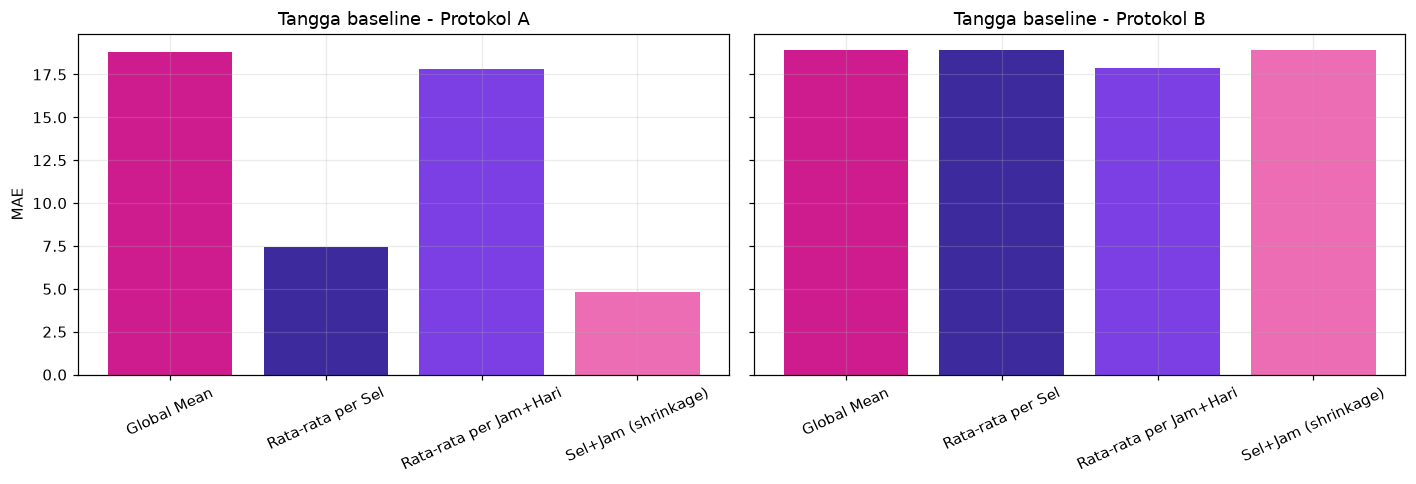

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, proto in zip(axes, ("A", "B")):
    sub = baseline_table[baseline_table["protocol"] == proto]
    short_labels = [s.replace("Baseline: ", "") for s in sub["predictor"]]
    ax.bar(short_labels, sub["MAE"], color=viz.BRAND_COLORS[:len(sub)])
    ax.set_title(f"Tangga baseline - Protokol {proto}")
    ax.set_ylabel("MAE" if proto == "A" else "")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
viz.savefig(fig, "02_tangga_baseline_MAE")
plt.show()


**Pengamatan penting (protokol B)**: baseline berbasis sel (`Rata-rata
per Sel` dan `Sel+Jam shrinkage`) kolaps menjadi identik dengan `Global Mean`.
Ini BUKAN bug - pada holdout spasial, seluruh sel di test tidak pernah muncul
di train, sehingga rantai fallback jatuh sampai ke global mean untuk 100%
baris. Inilah demonstrasi jujur bahwa baseline berbasis sel kehilangan
kekuatannya persis pada kondisi yang paling relevan untuk mengukur
generalisasi - bukan dipilih sebagai pembanding lemah.


## 4. Kandidat model dan pemilihan champion

Kandidat (tanpa hyperparameter tuning, sesuai batasan dokumen soal): **Ridge
Regression** (referensi linear), **Random Forest**, **XGBoost**. Seluruh
kandidat dilatih pada train protokol B dan dievaluasi pada test protokol B -
angka headline generalisasi.

Kriteria pemilihan champion bukan hanya MAE: waktu training dan ukuran
artefak `.joblib` ikut dipertimbangkan, karena CP3 memerlukan retrain
berulang dan API memerlukan waktu muat cepat saat startup.


In [8]:
comparison_candidates, fitted_b = modeling.train_candidates(
    protocols["B"]["train"], protocols["B"]["test"]
)
comparison_candidates.round(3)


,model,MAE,RMSE,R2,Spearman,train_seconds,artifact_kb
0,Model: Ridge Regression,6.188,8.422,0.868,0.955,0.014,1.1
1,Model: Random Forest,3.360,4.365,0.965,0.982,15.652,751447.2
2,Model: XGBoost,3.292,4.253,0.966,0.983,0.554,478.3


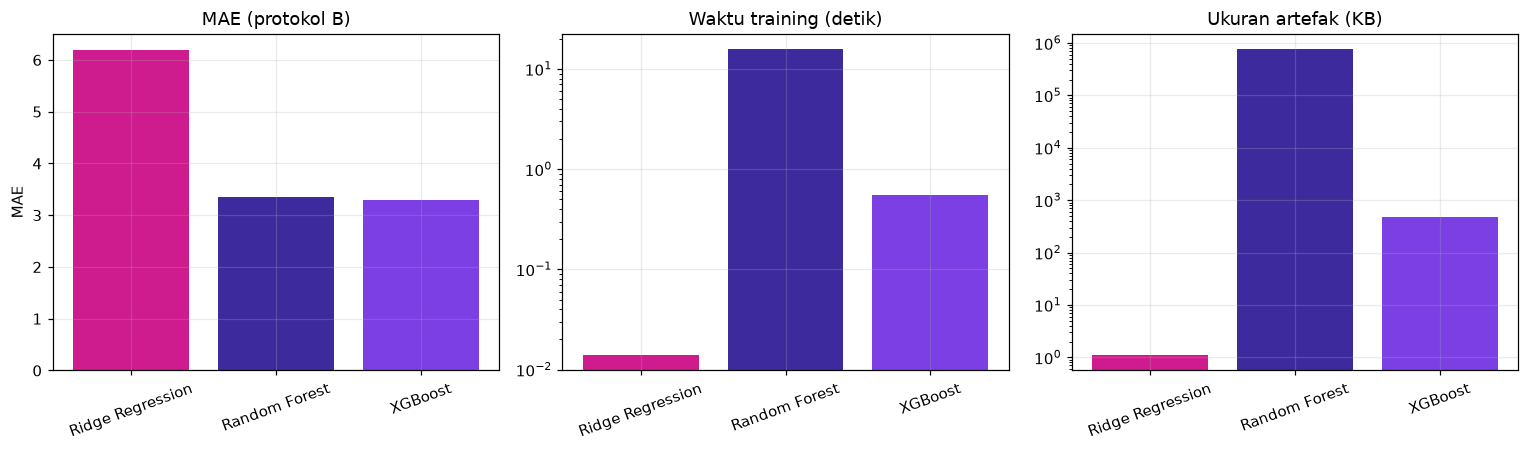

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
labels = [m.replace("Model: ", "") for m in comparison_candidates["model"]]
axes[0].bar(labels, comparison_candidates["MAE"], color=viz.BRAND_COLORS[:3])
axes[0].set_title("MAE (protokol B)"); axes[0].set_ylabel("MAE")
axes[1].bar(labels, comparison_candidates["train_seconds"], color=viz.BRAND_COLORS[:3])
axes[1].set_title("Waktu training (detik)"); axes[1].set_yscale("log")
axes[2].bar(labels, comparison_candidates["artifact_kb"], color=viz.BRAND_COLORS[:3])
axes[2].set_title("Ukuran artefak (KB)"); axes[2].set_yscale("log")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
viz.savefig(fig, "03_perbandingan_kandidat_model")
plt.show()


In [10]:
champion_name, champion_reason = modeling.select_champion(comparison_candidates)
print(f"Champion terpilih: {champion_name}\n")
print(f"Alasan: {champion_reason}")


Champion terpilih: Model: XGBoost

Alasan: MAE 2 kandidat setara dalam margin 0.5: Model: XGBoost (MAE 3.292), Model: Random Forest (MAE 3.360). Di antaranya, Model: XGBoost dipilih karena waktu training tercepat (0.55 detik) dan artefak terkecil (478.3 KB) - relevan karena CP3 memerlukan retrain berulang dan API memerlukan waktu muat cepat saat startup.


Perhatikan skala log pada waktu training dan ukuran artefak: Random
Forest 200 pohon menghasilkan artefak ratusan MB (tidak praktis untuk
retrain berulang maupun waktu muat API), sementara XGBoost mencapai akurasi
setara dengan artefak dan waktu training jauh lebih kecil. Ini bukan
kebetulan - lebar pohon XGBoost per estimator jauh lebih dangkal secara
default dibanding Random Forest yang tumbuh penuh.


## 5. Ablasi target encoding - kritik terhadap HO2

**Temuan HO2 yang ditolak**: `cell_risk_mean` (target encoding `cell_id`,
rata-rata target per sel yang dijadikan fitur) dipakai sebagai fitur
champion. Karena setiap sel muncul 168 kali dan split ACAK membuat hampir
semua sel hadir di train, fitur ini adalah **kebocoran target yang
tersamar** - penjelasan utama R2 0,95 pada HO2.

Ablasi ini membuktikan klaim itu secara empiris: latih `champion_name` DENGAN
dan TANPA `cell_risk_mean`, pada protokol A dan B.

**Hipotesis**: keunggulannya lenyap atau berbalik merugikan di protokol B,
karena sel test tidak pernah dilihat saat fit encoding sehingga fiturnya
kolaps ke global mean untuk seluruh baris test.


In [11]:
ablation_table = modeling.run_target_encoding_ablation(protocols, algo_name=champion_name)
ablation_table.round(3)


,protocol,predictor,predictor_type,MAE,RMSE,R2,Spearman,unseen_cell_pct
0,A,Model: XGBoost (tanpa target encoding),ablation,2.889,3.682,0.974,0.987,0.0
1,A,Model: XGBoost (dengan target encoding),ablation,2.889,3.675,0.974,0.987,0.0
2,B,Model: XGBoost (tanpa target encoding),ablation,3.292,4.253,0.966,0.983,100.0
3,B,Model: XGBoost (dengan target encoding),ablation,6.499,8.567,0.863,0.967,100.0


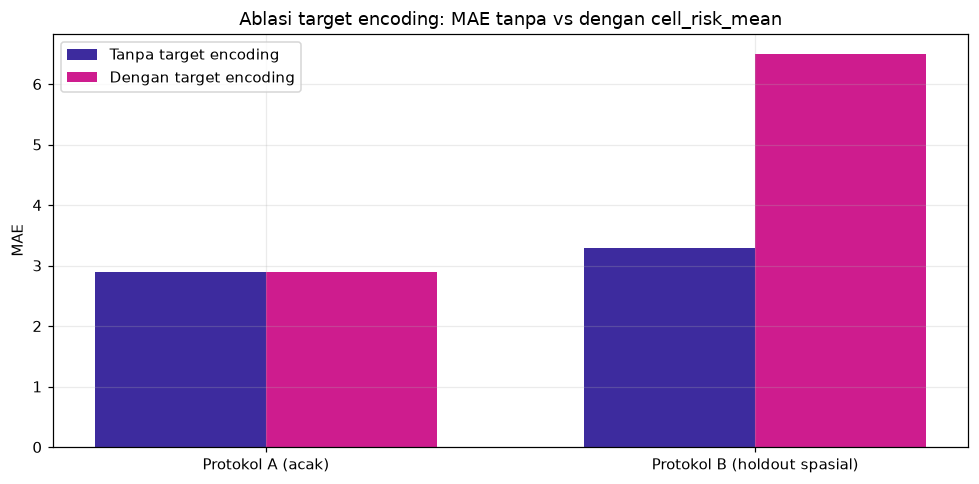

Perubahan MAE protokol A (dengan - tanpa): -0.000
Perubahan MAE protokol B (dengan - tanpa): +3.207


In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
width = 0.35
protos_order = ["A", "B"]
without_mae = [ablation_table.query("protocol == @p and predictor.str.contains('tanpa')")["MAE"].iloc[0] for p in protos_order]
with_mae = [ablation_table.query("protocol == @p and predictor.str.contains('dengan')")["MAE"].iloc[0] for p in protos_order]
x = np.arange(len(protos_order))
ax.bar(x - width/2, without_mae, width, label="Tanpa target encoding", color=viz.BRAND_INDIGO)
ax.bar(x + width/2, with_mae, width, label="Dengan target encoding", color=viz.BRAND_MAGENTA)
ax.set_xticks(x); ax.set_xticklabels(["Protokol A (acak)", "Protokol B (holdout spasial)"])
ax.set_ylabel("MAE"); ax.set_title("Ablasi target encoding: MAE tanpa vs dengan cell_risk_mean")
ax.legend()
plt.tight_layout()
viz.savefig(fig, "04_ablasi_target_encoding")
plt.show()

delta_a = with_mae[0] - without_mae[0]
delta_b = with_mae[1] - without_mae[1]
print(f"Perubahan MAE protokol A (dengan - tanpa): {delta_a:+.3f}")
print(f"Perubahan MAE protokol B (dengan - tanpa): {delta_b:+.3f}")


**Interpretasi**: pada protokol A, penambahan `cell_risk_mean` nyaris
tidak mengubah MAE - fitur agregat yang sudah ada (`crime_count`,
`neighbor_count_mean`, `lat_r`/`lon_r`) sudah cukup bagi model berbasis
pohon untuk secara implisit "menghafal" sel, sehingga target encoding tidak
menambah sinyal baru. Pada protokol B, `cell_risk_mean` justru **memperburuk**
MAE secara signifikan - persis seperti hipotesis: pada 100% baris test
bersel tak dikenal, fitur ini kolaps ke satu nilai konstan (global mean),
membanjiri model dengan sinyal yang salah alih-alih membantunya. Hasil ini
mengonfirmasi keputusan CP2 untuk **tidak** memakai target encoding pada
champion final.


## 6. Tabel perbandingan final

Satu tabel: protokol x (baseline/model) x empat metrik (MAE, RMSE, R2,
Spearman), plus persentase perbaikan model terhadap baseline TERKUAT pada
protokol yang sama.


In [13]:
def build_comparison_table(protocols, ladders, champions):
    rows = []
    for proto in ("A", "B", "C"):
        test_df = protocols[proto]["test"]
        y_true = test_df[F.TARGET_COLUMN].to_numpy()
        for label, pred in baselines.predict_baseline_ladder(ladders[proto], test_df).items():
            rows.append(evaluation.evaluate_row(y_true, pred, proto, label, "baseline"))
        model = champions[proto]
        pred_model = model.predict(F.assemble_feature_matrix(test_df))
        rows.append(evaluation.evaluate_row(y_true, pred_model, proto, f"Champion: {champions['name']}", "model"))
    return evaluation.add_improvement_column(pd.DataFrame(rows))

champion_a = modeling.make_model(champion_name)
champion_a.fit(F.assemble_feature_matrix(protocols["A"]["train"]), protocols["A"]["train"][F.TARGET_COLUMN].to_numpy())
champions = {"A": champion_a, "B": fitted_b[champion_name], "C": fitted_b[champion_name], "name": champion_name}

comparison_table = build_comparison_table(protocols, ladders, champions)
comparison_table.round(3)


,protocol,predictor,predictor_type,MAE,RMSE,R2,Spearman,improvement_vs_strongest_baseline_pct
0,A,Baseline: Global Mean,baseline,18.798,22.777,-0.000,NaN,-288.343
1,A,Baseline: Rata-rata per Sel,baseline,7.421,9.682,0.819,0.908,-53.308
2,A,Baseline: Rata-rata per Jam+Hari,baseline,17.819,21.659,0.096,0.286,-268.117
3,A,Baseline: Sel+Jam (shrinkage),baseline,4.841,6.323,0.923,0.961,0.000
4,A,Champion: Model: XGBoost,model,2.889,3.682,0.974,0.987,40.324
5,B,Baseline: Global Mean,baseline,18.905,23.198,-0.001,NaN,-5.823
6,B,Baseline: Rata-rata per Sel,baseline,18.905,23.198,-0.001,NaN,-5.823
7,B,Baseline: Rata-rata per Jam+Hari,baseline,17.864,22.126,0.090,0.282,0.000
8,B,Baseline: Sel+Jam (shrinkage),baseline,18.905,23.198,-0.001,NaN,-5.823
9,B,Champion: Model: XGBoost,model,3.292,4.253,0.966,0.983,81.571


In [14]:
headline = comparison_table.query("protocol == 'B' and predictor_type == 'model'").iloc[0]
strongest_baseline_b = comparison_table.query("protocol == 'B' and predictor_type == 'baseline'")["MAE"].min()
print("=== ANGKA HEADLINE (protokol B, holdout spasial) ===")
print(f"MAE champion   : {headline['MAE']:.3f}")
print(f"MAE baseline terkuat: {strongest_baseline_b:.3f}")
print(f"Perbaikan      : {headline['improvement_vs_strongest_baseline_pct']:.1f}%")
print(f"R2             : {headline['R2']:.3f}")
print(f"Spearman       : {headline['Spearman']:.3f}")


=== ANGKA HEADLINE (protokol B, holdout spasial) ===
MAE champion   : 3.292
MAE baseline terkuat: 17.864
Perbaikan      : 81.6%
R2             : 0.966
Spearman       : 0.983


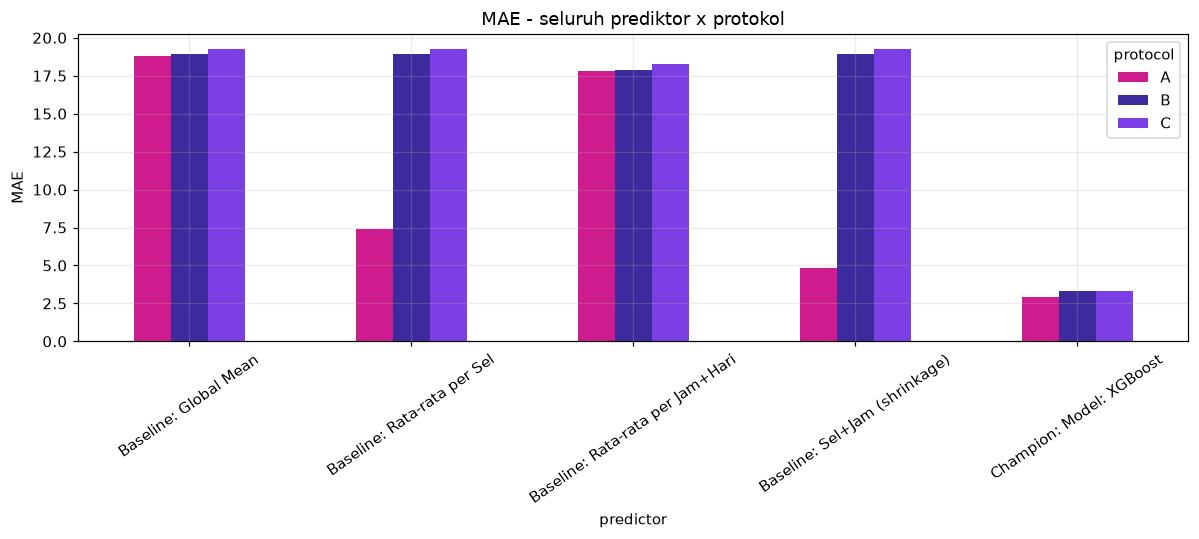

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
pivot = comparison_table.pivot_table(index="predictor", columns="protocol", values="MAE", aggfunc="first")
pivot = pivot.reindex(comparison_table.drop_duplicates("predictor")["predictor"])
pivot.plot(kind="bar", ax=ax, color=viz.BRAND_COLORS[:3])
ax.set_ylabel("MAE"); ax.set_title("MAE - seluruh prediktor x protokol")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
viz.savefig(fig, "05_perbandingan_final_MAE")
plt.show()


**Catatan pembacaan R2**: R2 protokol A (interpolasi grid dikenal)
secara struktural lebih tinggi daripada protokol B, bukan karena model versi
A "lebih baik", melainkan karena soalnya lebih mudah (sel sudah dihafal
sebagian oleh fitur agregat). R2 protokol B adalah representasi generalisasi
yang jujur dan menjadi rujukan utama laporan ini.


## 7. Evaluasi bersegmen (protokol B)

MAE per kuintil label, per kelompok jam, porsi baris dengan error besar, dan
sel dengan error terburuk - supaya nilai tambah model terlihat di seluruh
segmen, bukan hanya rata-rata keseluruhan.


In [16]:
baseline_b_strongest = baselines.predict_baseline_ladder(ladder_b, protocols["B"]["test"])[
    baselines.BASELINE_LABELS["cell_hour_shrunk"]
]
pred_model_b = champions["B"].predict(F.assemble_feature_matrix(protocols["B"]["test"]))

segmented = evaluation.segmented_evaluation(
    protocols["B"]["test"], protocols["B"]["test"][F.TARGET_COLUMN].to_numpy(),
    pred_model_b, baseline_b_strongest,
)
print(f"Spearman model   : {segmented['spearman_model']:.3f}")
print(f"Spearman baseline: {segmented['spearman_baseline']:.3f}  (NaN wajar bila baseline kolaps ke konstanta)")
print("\nMAE per kuintil label:")
segmented["per_quintile"].round(3)


Spearman model   : 0.983
Spearman baseline: nan  (NaN wajar bila baseline kolaps ke konstanta)

MAE per kuintil label:


,err_model,err_baseline,improvement_pct
quintile,,,
Q1 (aman),2.454,31.488,92.207
Q2,3.221,14.888,78.364
Q3,3.169,3.315,4.390
Q4,3.540,10.930,67.613
Q5 (rawan),4.077,33.899,87.973


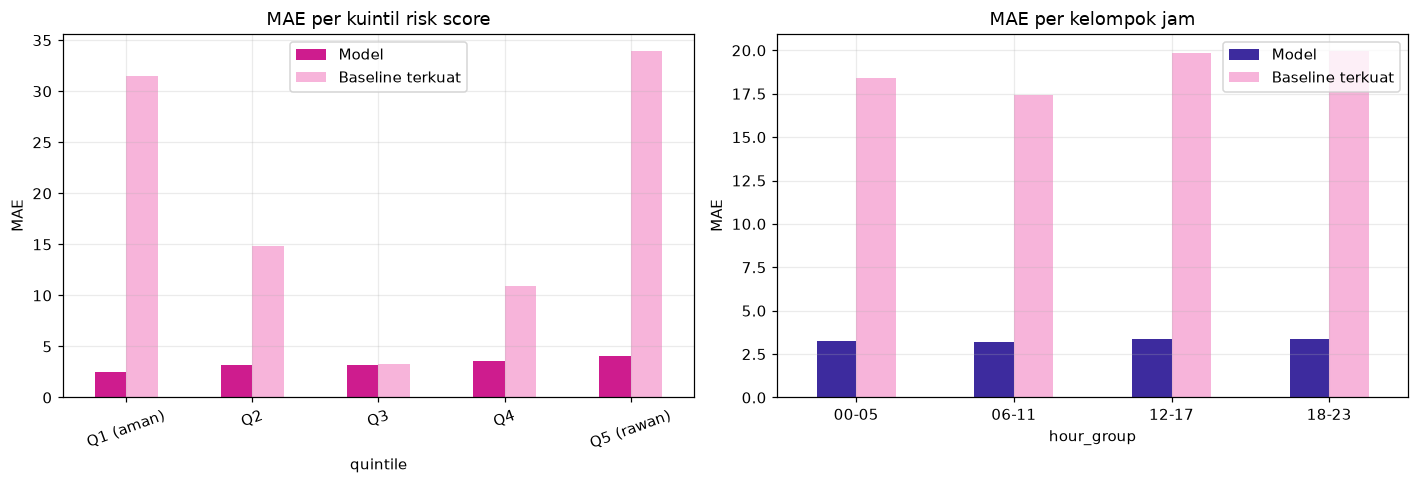

Porsi baris dengan error besar:
  |error| >  5: model 21.51% | baseline 83.41%
  |error| > 10: model  2.51% | baseline 67.90%
  |error| > 20: model  0.02% | baseline 41.76%

5 sel dengan MAE model terburuk (n>=10):


,mean,count
cell_id,,
41.88_-87.77,10.464813,168
41.8_-87.58,9.708714,168
41.88_-87.74,7.257304,168
41.89_-87.74,6.179662,168
41.9_-87.62,6.094246,168


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
q = segmented["per_quintile"]
q[["err_model", "err_baseline"]].plot(kind="bar", ax=axes[0], color=[viz.BRAND_MAGENTA, viz.BRAND_LIGHT])
axes[0].set_title("MAE per kuintil risk score"); axes[0].set_ylabel("MAE"); axes[0].legend(["Model", "Baseline terkuat"])
axes[0].tick_params(axis="x", rotation=20)

h = segmented["per_hour_group"]
h[["err_model", "err_baseline"]].plot(kind="bar", ax=axes[1], color=[viz.BRAND_INDIGO, viz.BRAND_LIGHT])
axes[1].set_title("MAE per kelompok jam"); axes[1].set_ylabel("MAE"); axes[1].legend(["Model", "Baseline terkuat"])
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
viz.savefig(fig, "06_evaluasi_bersegmen")
plt.show()

print("Porsi baris dengan error besar:")
for t, v in segmented["large_error_fractions"].items():
    print(f"  |error| > {t:>2}: model {v['model_pct']:5.2f}% | baseline {v['baseline_pct']:5.2f}%")

print("\n5 sel dengan MAE model terburuk (n>=10):")
segmented["worst_cells"]


## 8. Permutation importance (protokol B)

Wajib untuk memverifikasi champion tidak bergantung pada satu fitur yang
hampir sirkular dengan label - kekhawatiran yang sama yang mendasari
penolakan `cell_risk_mean` di bagian 5.


In [18]:
importance_table = modeling.compute_permutation_importance(
    champions["B"], F.assemble_feature_matrix(protocols["B"]["test"]),
    protocols["B"]["test"][F.TARGET_COLUMN].to_numpy(),
)
importance_table.round(3)


,feature,importance_mean,importance_std
0,neighbor_count_mean,13.537,0.062
1,crime_count,5.992,0.036
2,lon_r,1.465,0.015
3,lat_r,1.102,0.017
4,violent_share,0.479,0.008
5,cell_total_count,0.238,0.011
6,hour,0.091,0.003
7,hour_cos,0.080,0.002
8,arrest_rate,0.038,0.003
9,dow,0.032,0.002


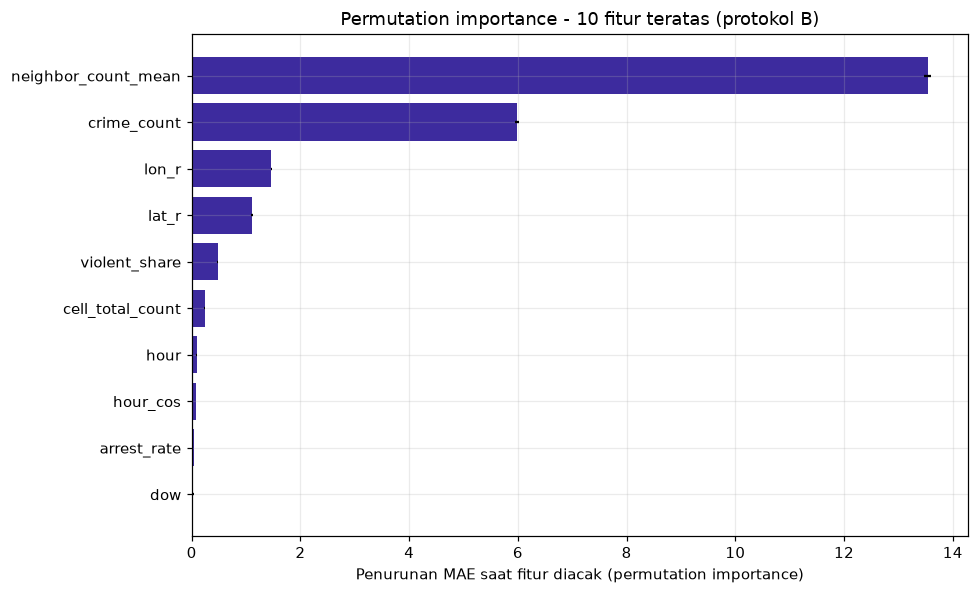

In [19]:
fig, ax = plt.subplots(figsize=(9, 5.5))
top = importance_table.head(10).iloc[::-1]
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"], color=viz.ACCENT2)
ax.set_xlabel("Penurunan MAE saat fitur diacak (permutation importance)")
ax.set_title("Permutation importance - 10 fitur teratas (protokol B)")
plt.tight_layout()
viz.savefig(fig, "07_permutation_importance")
plt.show()


**Interpretasi**: kontribusi terbesar datang dari `neighbor_count_mean`
dan `crime_count` - keduanya fitur agregat historis (bukan `risk_score` itu
sendiri maupun turunan langsungnya), jadi bukan kebocoran label. Tidak ada
satu fitur pun yang mendominasi >90% importance, artinya champion menyebar
sinyalnya lintas beberapa fitur spasial-temporal, bukan bergantung pada satu
proxy nyaris-sirkular.


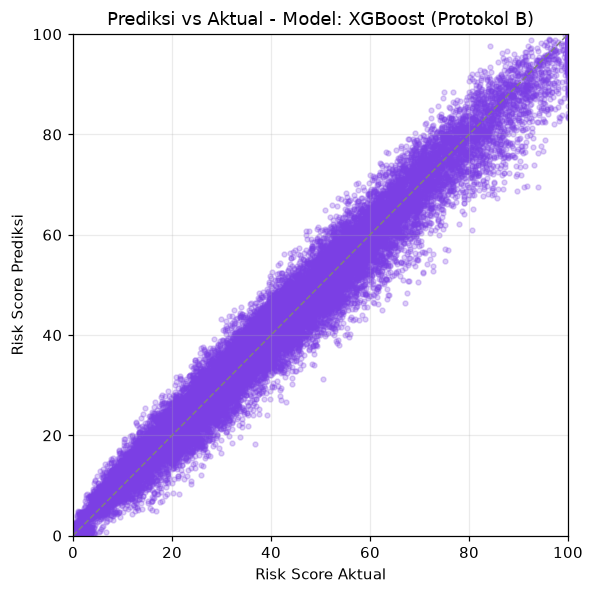

In [20]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
y_test_b = protocols["B"]["test"][F.TARGET_COLUMN].to_numpy()
ax.scatter(y_test_b, pred_model_b, alpha=0.25, s=10, color=viz.BRAND_VIOLET)
ax.plot([0, 100], [0, 100], "--", color="gray", linewidth=1)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel("Risk Score Aktual"); ax.set_ylabel("Risk Score Prediksi")
ax.set_title(f"Prediksi vs Aktual - {champion_name} (Protokol B)")
plt.tight_layout()
viz.savefig(fig, "08_prediksi_vs_aktual")
plt.show()


## 9. Bundle model, registry, metrics, dan output JSON

Holdout (protokol A/B/C) hanya dipakai untuk **mengukur** generalisasi secara
jujur. Model yang dilayani API dilatih ulang pada **seluruh dataset** (100%)
setelah evaluasi selesai - praktik standar, supaya model produksi tidak
sengaja buta terhadap 20% sel yang sengaja ditahan untuk evaluasi.

Bundle `.joblib` mengunci: estimator, `feature_columns` (urutan terkunci),
`label_params`, `model_version`, `trained_at`, ringkasan metrics, dan sidik
jari dataset. `registry.json` mencatat satu entri `v1` - kerangka yang sama
akan menampung entri-entri baru saat Checkpoint 3 menambah continual
learning, tanpa perubahan skema maupun kontrak API.


In [21]:
final_model = modeling.make_model(champion_name)
final_model.fit(F.assemble_feature_matrix(df), df[F.TARGET_COLUMN].to_numpy())

metrics_summary = {
    "protocol_A": comparison_table[comparison_table["protocol"] == "A"].to_dict(orient="records"),
    "protocol_B": comparison_table[comparison_table["protocol"] == "B"].to_dict(orient="records"),
    "protocol_C": comparison_table[comparison_table["protocol"] == "C"].to_dict(orient="records"),
}

bundle = registry.build_bundle(
    model=final_model, algorithm=champion_name, metrics_summary=metrics_summary,
    dataset_df=df, label_params=label_params, model_version=MODEL_VERSION,
)
artifact_path = registry.save_bundle(bundle, MODEL_BUNDLE_PATH)
registry_entries = [registry.build_registry_entry(bundle, artifact_path, status="champion")]
registry.write_registry(registry_entries, REGISTRY_PATH)

full_metrics = {
    "champion_algorithm": champion_name,
    "champion_selection_reason": champion_reason,
    "unseen_cell_verification": protocols["stats"],
    "shrinkage_m_selected": {"A": ladder_a["best_m"], "B": ladder_b["best_m"]},
    "candidate_comparison_protocol_B": comparison_candidates.to_dict(orient="records"),
    "final_comparison_table": comparison_table.to_dict(orient="records"),
    "target_encoding_ablation": ablation_table.to_dict(orient="records"),
    "segmented_evaluation_protocol_B": {
        "per_quintile": segmented["per_quintile"].reset_index().to_dict(orient="records"),
        "per_hour_group": segmented["per_hour_group"].reset_index().to_dict(orient="records"),
        "large_error_fractions": segmented["large_error_fractions"],
        "worst_cells": segmented["worst_cells"].reset_index().to_dict(orient="records"),
        "spearman_model": segmented["spearman_model"],
        "spearman_baseline": segmented["spearman_baseline"],
    },
    "permutation_importance_protocol_B": importance_table.to_dict(orient="records"),
    "dataset_fingerprint": bundle["dataset_fingerprint"],
}
registry.write_metrics(full_metrics, path=METRICS_PATH)

print(f"Bundle   -> {artifact_path}")
print(f"Registry -> {REGISTRY_PATH}")
print(f"Metrics  -> {METRICS_PATH}")


Bundle   -> /Users/fransiskaadinda/Downloads/sistech/FP_MLOps_Kelompok 1/models/model_bundle_v1.joblib
Registry -> /Users/fransiskaadinda/Downloads/sistech/FP_MLOps_Kelompok 1/models/registry.json
Metrics  -> /Users/fransiskaadinda/Downloads/sistech/FP_MLOps_Kelompok 1/models/metrics.json


In [22]:
import train as train_script

output_payload = train_script.build_representative_output(bundle, df)
registry.write_json(output_payload, OUTPUT_JSON_PATH)
print(f"Output   -> {OUTPUT_JSON_PATH} ({output_payload['n_predictions']} prediksi)")
pd.DataFrame(output_payload["predictions"]).head(10)


Output   -> /Users/fransiskaadinda/Downloads/sistech/FP_MLOps_Kelompok 1/outputs/FP_MLOps_Kelompok 1_Output.json (100 prediksi)


,cell_id,lat,lon,datetime,time_slot_label,risk_score,level,data_coverage
0,42.01_-87.91,42.01,-87.91,2026-04-14T09:00:00,weekday_morning,7.38,Low,historical_data
1,42.01_-87.91,42.01,-87.91,2026-04-14T23:00:00,weekday_night,0.68,Low,historical_data
2,42.01_-87.91,42.01,-87.91,2026-04-11T23:00:00,weekend_night,0.32,Low,historical_data
3,42.01_-87.91,42.01,-87.91,2026-04-12T02:00:00,weekend_early_morning,0.35,Low,historical_data
4,41.79_-87.8,41.79,-87.80,2026-04-14T09:00:00,weekday_morning,17.73,Low,historical_data
5,41.79_-87.8,41.79,-87.80,2026-04-14T23:00:00,weekday_night,18.00,Low,historical_data
6,41.79_-87.8,41.79,-87.80,2026-04-11T23:00:00,weekend_night,27.96,Medium,historical_data
7,41.79_-87.8,41.79,-87.80,2026-04-12T02:00:00,weekend_early_morning,22.92,Low,historical_data
8,42.0_-87.8,42.00,-87.80,2026-04-14T09:00:00,weekday_morning,18.41,Low,historical_data
9,42.0_-87.8,42.00,-87.80,2026-04-14T23:00:00,weekday_night,15.27,Low,historical_data


## 10. Ringkasan keputusan dan keterbatasan metodologis

### Ringkasan keputusan

- **Champion**: dipilih di bagian 4 berdasarkan MAE protokol B, waktu
  training, dan ukuran artefak - lihat teks alasan yang tercetak di sana.
- **Target encoding `cell_id` DITOLAK** sebagai fitur champion - ablasi bagian
  5 menunjukkan keunggulannya lenyap di protokol A dan berbalik merugikan di
  protokol B (leakage bersyarat pada split).
- **Baseline terkuat** (tingkat 4, shrinkage) adalah lantai pembanding utama,
  bukan global mean - model harus mengalahkan lantai yang sudah tinggi.
- **Angka headline generalisasi** adalah metrik protokol B, bukan protokol A.

### Keterbatasan metodologis (wajib dibaca sebelum dikonsumsi Front-End)

1. **Holdout temporal tidak mungkin** di CP2: satu baris adalah profil agregat
   lintas tahun, bukan observasi bertanggal. Regenerasi snapshot pada cutoff
   tanggal lebih baru adalah pekerjaan CP3.
2. **Framing label**: `risk_score` adalah fungsi deterministik dari data
   kejahatan historis. Performa tinggi TIDAK BOLEH diklaim sebagai "model
   memprediksi kejahatan". Model ini adalah **aproksimasi cepat yang dapat
   digeneralisasi** atas fungsi label yang mahal dihitung; nilai tambahnya
   adalah kemampuan menilai sel dan slot tanpa data historis memadai, bukan
   mereplikasi perhitungan yang sudah ada.
3. **Konteks geografis**: seluruh pola berasal dari Chicago; konteks sosial,
   geografis, dan penegakan hukum berbeda dari Indonesia (lihat `disclaimer`
   pada setiap response API).
4. **Tanpa hyperparameter tuning** - sesuai batasan eksplisit dokumen soal.

### Kesiapan Checkpoint 3

`model_version` dan `last_updated` sudah ada di setiap response API sejak
CP2. `registry.json` sudah berformat entri-per-versi (satu entri `v1`
sekarang), bundle `.joblib` sudah berversi, sehingga CP3 (continual learning,
drift detection, retraining berkala, monitoring) tinggal menambah entri baru
tanpa perubahan kontrak API maupun refactor arsitektur besar.
